# 🧠 Stage 6 · Classifying · Neural Network

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vshabanova/bachelor/blob/main/06_neural-networks/neural-network.ipynb)

**Topic of the week:** Image Classification with Neural Networks · **Lecture:** Thu 08.10 · **Startup question:** *Can a network learn its own features, straight from the pixels?*

The random forest only sees what stage 5 told it to look at. A convolutional network learns its own filters from the segmented pixels. In the pipeline it runs next to the forest, so every run is a head-to-head. Out of the box it loses. Let's find out why.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`classifying_cnn/action.yaml`](classifying_cnn/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Classifying.md`](Todo_Classifying.md) |
| Code | `stages/s6_classifying.py → train_cnn()` |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "vshabanova/bachelor"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

## The data: pixels, not features
The CNN takes the frames that stage 4 passed on (`I_train`, `I_test`), not the HOG and LBP vectors.

✔ Stages up to 'extracting' ran with your tinker-zone values
540 training frames of (128, 128, 1) , 90 test frames


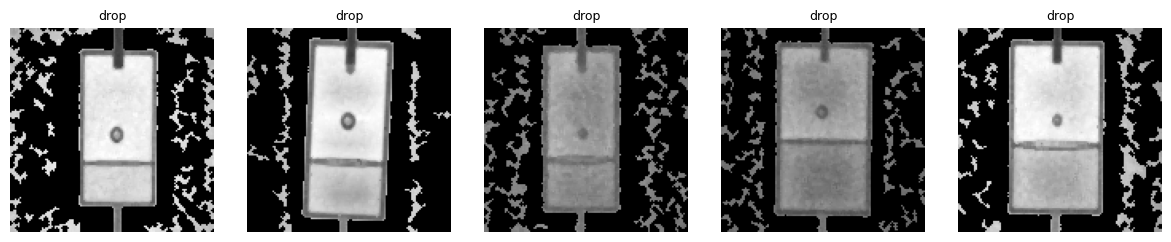

In [2]:
cfg = prepare("extracting")
d = np.load("build/extracting/features.npz")
classes = [str(c) for c in d["classes"]]
It, Ie, y_train, y_test = d["I_train"], d["I_test"], d["y_train"], d["y_test"]
if It.ndim == 3:
    It, Ie = It[..., None], Ie[..., None]
print(f"{len(It)} training frames of {It.shape[1:]} , {len(Ie)} test frames")
show([It[k, ..., 0] for k in range(0, 60, 12)], [classes[y_train[k]] for k in range(0, 60, 12)], size=2.4)

## Train it with your tinker-zone values
This is `train_cnn()`, the function CI runs, with `cfg["neural_network"]`. On a laptop CPU it takes a minute or two; a CUDA GPU would do it in seconds.

I0000 00:00:1790510940.623581     594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790510941.081194     594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790510942.894928     594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPUs TensorFlow can see: none, training on the CPU


Epoch 1/40


15/15 - 2s - 122ms/step - accuracy: 0.3747 - loss: 1.1073 - val_accuracy: 0.3210 - val_loss: 1.1002


...

15/15 - 1s - 41ms/step - accuracy: 0.9978 - loss: 0.0262 - val_accuracy: 0.7778 - val_loss: 0.7333


Epoch 39/40


15/15 - 1s - 43ms/step - accuracy: 0.9978 - loss: 0.0138 - val_accuracy: 0.7901 - val_loss: 0.7115


Epoch 40/40


15/15 - 1s - 42ms/step - accuracy: 0.9978 - loss: 0.0121 - val_accuracy: 0.8272 - val_loss: 0.7000


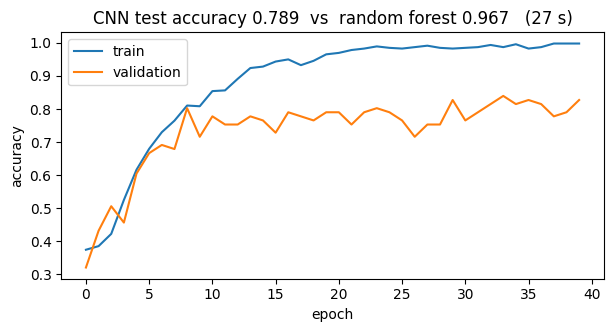

In [3]:
try:
    import tensorflow as tf
except ImportError:
    tf = None
    print("TensorFlow isn't installed: pip install -r requirements-cnn.txt (Colab already has it)")
if tf:
    import time
    from stages.s6_classifying import train_cnn
    print("GPUs TensorFlow can see:", tf.config.list_physical_devices("GPU") or "none, training on the CPU")
    t0 = time.time()
    model, hist = train_cnn(It, y_train, len(classes), cfg["neural_network"], seed=42)
    cnn_acc = (model.predict(Ie, verbose=0).argmax(1) == y_test).mean()
    rf_file = "build/random_forest/metrics.json"
    rf_acc = json.load(open(rf_file))["metrics"]["test accuracy"] if os.path.exists(rf_file) else float("nan")
    plt.figure(figsize=(7, 3.2)); plt.plot(hist["accuracy"], label="train"); plt.plot(hist["val_accuracy"], label="validation")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
    plt.title(f"CNN test accuracy {cnn_acc:.3f}  vs  random forest {rf_acc:.3f}   ({time.time() - t0:.0f} s)"); plt.show()

## What did the first layer learn?
Every filter of the first convolution is a 3 × 3 grid of weights, like the Sobel kernel of stage 3, except nobody designed it. Below: the filters, and what each one makes of a test frame.

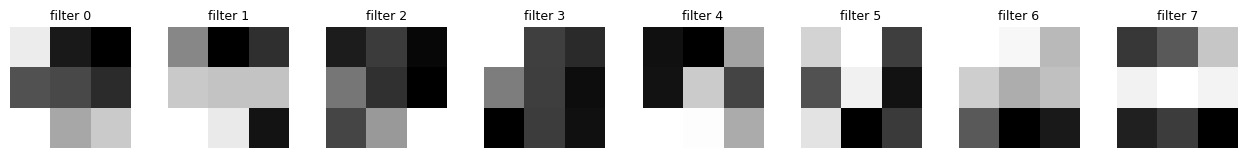

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 1))
  warnings.warn(msg)


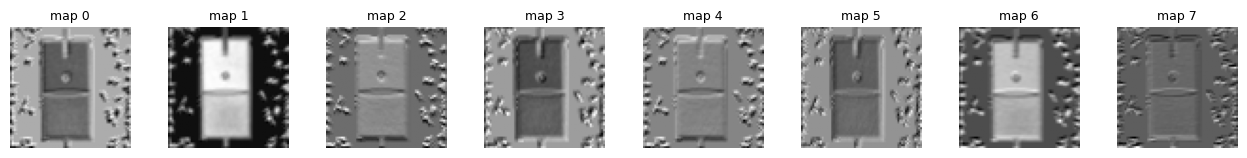

In [4]:
if tf:
    conv = next(l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D))
    w = conv.get_weights()[0][:, :, 0, :]
    show([w[..., k] for k in range(min(8, w.shape[-1]))], [f"filter {k}" for k in range(min(8, w.shape[-1]))], size=1.6)
    probe = tf.keras.Model(model.inputs, conv.output)
    maps = probe(Ie[:1]).numpy()[0]
    show([maps[..., k] for k in range(min(8, maps.shape[-1]))], [f"map {k}" for k in range(min(8, maps.shape[-1]))], size=1.6)

## 🧪 Your turn
1. Look at the learning curve. Training accuracy near 100 %, validation far below: what is the network doing with 270 real frames (and their augmented copies)?
2. Fight overfitting: `dropout: 0.5`, fewer `epochs`, or more data with `augment_copies: 3` in stage 5. Which helps most?
3. `batch_norm: true`, then `head: gap`. Global average pooling forgets *where* things are. Why does that hurt a drip detector in particular?
4. `learning_rate` 0.01 and 0.0001. Cauchy's step downhill: too big, too small?
5. Set `enabled: "true"` in the tinker zone and let CI run both models. Which one would you ship?

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.